# Density crystallography of α-Li₂SO₄

`gemdat.density_crystallography` fits an average-structure model **directly to the MD
density grid**: fold the supercell, symmetrise with a space group, then fit one Gaussian
per Wyckoff orbit and refine its width (→ *U*<sub>iso</sub>), how the density is shared
between orbits and, optionally, a free position.

This notebook does that for **plastic-crystal α-Li₂SO₄**, using T. Famprikis's ab initio MD
run: a 2×2×2 supercell of the Fm-3m cell (224 atoms), 1000 K, 2 fs steps. It follows the
same S → Li → O order as his reference scripts (`fit_densities_{S,Li,O}.py`) and compares
the results with Table I of the manuscript *Refinement of the Average Structure of
Dynamically Disordered α-Lithium Sulfate from Molecular Dynamics*.

1. **The trajectory**: which species move, and how.
2. **From atoms to a density**: the origin, folding and symmetrising.
3. **Sulfur** on 4a.
4. **Lithium**: 8c + 4b, the split 32f + 4b model, and a test of the inversion centre.
5. **Oxygen**: where the O atoms around S actually sit, and which Wyckoff model
   (32f, 48h or 96j) describes them.
6. **Summary** against Table I.

The trajectory is the gemdat cache shipped with the reference scripts
(`vasprun.xml.12a3e781.cache`, 435 MB). It is not part of the repository, so point `DATA`
at your copy.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import map_coordinates
from skimage.measure import marching_cubes

from gemdat import Trajectory
from gemdat.density_crystallography import (
    fit_density_model,
    fold_supercell,
    rank_spacegroups,
    symmetrize_density,
    trajectory_to_symmetrized_density,
    wyckoff_orbit,
)

DATA = Path('../../local/li2so4/vasprun.xml.12a3e781.cache')
EQUILIBRATION_CUTOFF = 6007  # frames dropped as equilibration, as in the reference scripts
RESOLUTION = 0.16  # Å, as in the reference scripts
SUPERCELL = (2, 2, 2)
SPECIES = ('S', 'Li', 'O')
ATOMS_PER_CELL = {'S': 4, 'Li': 8, 'O': 16}  # conventional Fm-3m cell, Z = 4

# Table I of the manuscript (a = 7.11 Å); U in Å².
TABLE_I = {
    'S 4a U_iso': 0.134,
    'Li tetrahedral fraction': 0.866,
    'Li 8c U_iso': 0.214,
    'Li 4b U_iso': 0.634,
    'O 96j y': 0.1011,
    'O 96j z': 0.1779,
    'O 96j U_eq': (0.1783 + 0.17784 + 0.1902) / 3,
}

Plot helpers. Densities use a single-hue sequential scale; residuals use a diverging scale
that is neutral grey at zero (blue: observed above model, orange: model above observed).
Planes are sampled from the periodic grid by trilinear interpolation, with voxel `i`
centred on (i+½)/n, which is the `Volume` convention the module uses.

In [2]:
BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, MUTED, GRID = '#0b0b0b', '#52514e', '#e3e2dd'
COLORS = {'S': '#c9a227', 'Li': AQUA, 'O': ORANGE}

SEQ = LinearSegmentedColormap.from_list(
    'seq', ['#fcfcfb', '#d6e5f7', '#8db8ec', '#2a78d6', '#154a8c', '#0b2748']
)
DIV = LinearSegmentedColormap.from_list(
    'div', ['#7a2e0e', ORANGE, '#f4c7b0', '#e8e7e3', '#b5d0f2', BLUE, '#0f3a6e']
)

plt.rcParams.update(
    {
        'figure.dpi': 100,
        'font.size': 10,
        'axes.edgecolor': MUTED,
        'axes.labelcolor': INK,
        'axes.titlecolor': INK,
        'axes.titlesize': 10,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.grid': True,
        'grid.color': GRID,
        'grid.linewidth': 0.6,
        'xtick.color': MUTED,
        'ytick.color': MUTED,
        'legend.frameon': False,
        'lines.linewidth': 2,
        'axes.axisbelow': True,
    }
)


def sample(grid, frac):
    # Interpolate a periodic grid at fractional coordinates frac (..., 3).
    idx = np.mod(frac, 1.0) * np.array(grid.shape) - 0.5
    return map_coordinates(grid, np.moveaxis(idx, -1, 0), order=1, mode='grid-wrap')


def plane(grid, origin, e1, e2, n=176):
    # Density on origin + u*e1 + v*e2 for u, v in [0, 1), as an imshow image (rows = v).
    t = (np.arange(n) + 0.5) / n
    u, v = np.meshgrid(t, t, indexing='ij')
    frac = np.asarray(origin) + u[..., None] * np.asarray(e1) + v[..., None] * np.asarray(e2)
    return sample(grid, frac).T


def show(
    ax,
    image,
    *,
    extent=(0, 1, 0, 1),
    cmap=SEQ,
    vmin=None,
    vmax=None,
    title='',
    labels=('x', 'y'),
):
    im = ax.imshow(image, origin='lower', extent=extent, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set(title=title, xlabel=labels[0], ylabel=labels[1])
    ax.grid(False)
    return im


DIAGONAL_PLANE = dict(origin=(0, 0, 0), e1=(1, 1, 0), e2=(0, 0, 1))  # the (1-10) plane


def compare_maps(
    observed, model, *, origin, e1, e2, title, labels=('x', 'y'), extent=(0, 1, 0, 1)
):
    # Observed | model | observed - model on one plane, both grids normalised to sum 1.
    o = plane(observed / observed.sum(), origin, e1, e2)
    m = plane(model / model.sum(), origin, e1, e2)
    vmax = max(o.max(), m.max())
    rmax = np.abs(o - m).max()
    fig, axs = plt.subplots(1, 3, figsize=(12, 3.9), layout='constrained')
    show(axs[0], o, vmin=0, vmax=vmax, title='observed', labels=labels, extent=extent)
    im = show(axs[1], m, vmin=0, vmax=vmax, title='model', labels=labels, extent=extent)
    fig.colorbar(im, ax=axs[:2], shrink=0.85, label='density (normalised)')
    im = show(
        axs[2],
        o - m,
        cmap=DIV,
        vmin=-rmax,
        vmax=rmax,
        title='observed − model',
        labels=labels,
        extent=extent,
    )
    fig.colorbar(im, ax=axs[2], shrink=0.85, label='residual')
    fig.suptitle(title, color=INK)
    return fig


def line(grid, start, stop, n=241):
    t = np.linspace(0, 1, n)
    frac = np.asarray(start) + t[:, None] * (np.asarray(stop) - np.asarray(start))
    return t, sample(grid, frac)


def sites_table(result):
    # One row per refined orbit; site occupancy = atoms per cell * fraction / multiplicity.
    rows = []
    for site in result.sites:
        rows.append(
            {
                'specie': site.specie,
                'multiplicity': site.multiplicity,
                'position': tuple(np.round(site.position, 4)),
                'density fraction': round(site.occupancy, 4),
                'site occupancy': round(
                    ATOMS_PER_CELL[site.specie] * site.occupancy / site.multiplicity, 4
                ),
                'U_iso (Å²)': round(site.u_iso, 4),
                'split (Å)': None if site.displacement is None else round(site.displacement, 3),
            }
        )
    return pd.DataFrame(rows)


def isosurface(ax, grid, level, color, alpha=0.5):
    # Periodic isosurface of a unit-cell grid in fractional coordinates.
    padded = np.pad(grid, 1, mode='wrap')
    verts, faces, *_ = marching_cubes(padded, level=level)
    verts = (verts - 0.5) / np.array(grid.shape)
    keep = np.all((verts[faces] >= -0.02) & (verts[faces] <= 1.02), axis=(1, 2))
    ax.plot_trisurf(
        *verts[:, :2].T, faces[keep], verts[:, 2], color=color, alpha=alpha, lw=0, shade=True
    )

## 1. The trajectory

Load the cache, correct the drift using the sulfur atoms (as the reference scripts do) and
drop the first 6007 frames as equilibration.

In [3]:
full = Trajectory.from_cache(DATA)
traj = full.apply_drift_correction(fixed_species=['S'])[EQUILIBRATION_CUTOFF:]
del full

a = traj.lattice[0, 0] / SUPERCELL[0]  # conventional cell edge
pd.Series(
    {
        'atoms': len(traj.species),
        'composition': traj.get_structure(0).composition.formula,
        'temperature (K)': traj.metadata['temperature'],
        'time step (fs)': traj.time_step * 1e15,
        'frames used': len(traj),
        'time used (ps)': round(len(traj) * traj.time_step * 1e12, 1),
        'supercell edge (Å)': round(traj.lattice[0, 0], 3),
        'conventional a (Å)': round(a, 3),
    }
).to_frame('value')

,value
atoms,224
composition,Li64 S32 O128
temperature (K),1000.0
time step (fs),2.0
frames used,75000
time used (ps),150.0
supercell edge (Å),14.22
conventional a (Å),7.11


How far does each atom get from where it started? The mean distance per species, using
every 10th frame (unwrapped across the periodic boundaries):

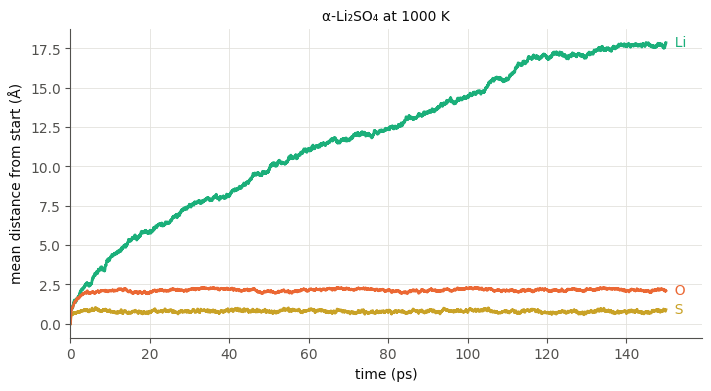

,S,Li,O
after 150 ps (Å),0.89,17.86,2.09


In [4]:
every = 10
sub = traj[::every]
distances = sub.distances_from_base_position()  # (atoms, frames)
time_ps = np.arange(distances.shape[1]) * every * traj.time_step * 1e12
symbols = np.array([s.symbol for s in traj.species])

fig, ax = plt.subplots(figsize=(7, 3.8), layout='constrained')
for sp in SPECIES:
    d = distances[symbols == sp]
    ax.plot(time_ps, d.mean(axis=0), color=COLORS[sp], label=sp)
    ax.text(time_ps[-1], d.mean(axis=0)[-1], f'  {sp}', color=COLORS[sp], va='center')
ax.set(xlabel='time (ps)', ylabel='mean distance from start (Å)', title='α-Li₂SO₄ at 1000 K')
ax.set_xlim(0, time_ps[-1] * 1.06)
plt.show()

pd.DataFrame(
    {sp: [distances[symbols == sp][:, -1].mean()] for sp in SPECIES}, index=['after 150 ps (Å)']
).round(2)

Li diffuses: its distance keeps growing. S does not; it vibrates about its lattice site.
O levels off after a short time at about the size of a sulfate ion (the S–O bond is
≈1.5 Å): the SO₄²⁻ ions tumble in place, which is what makes this a plastic crystal.
Neither Li nor O stays near one position, so a single Gaussian per atom will not
describe either. The rest of the notebook asks what does.

## 2. From atoms to a density

### 2a. Where is the origin?

The reference S script fits an *origin shift* along with the S width, and subtracts it
from the Li and O coordinates, to allow for the simulation box drifting during
thermalisation. We can measure that shift directly from the data: fold each S position
into the conventional cell and take its offset from the nearest lattice point.

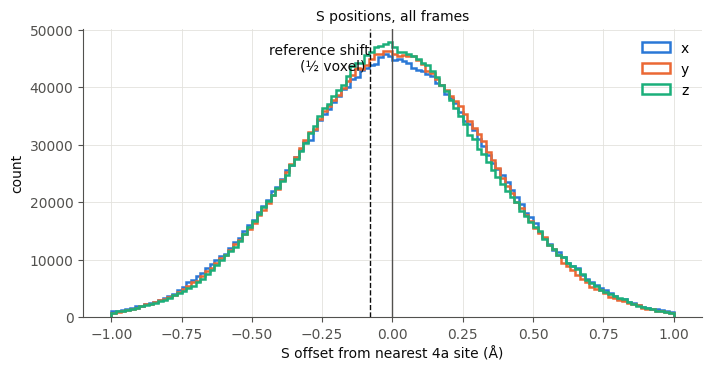

,mean S offset (fraction),reference fitted shift (fraction),−½ voxel (fraction)
x,-0.0,-0.01081,-0.01136
y,0.0,-0.01110,-0.01136
z,0.0,-0.01183,-0.01136


In [5]:
raw = {
    sp: traj.filter(sp).to_volume(resolution=RESOLUTION).data for sp in SPECIES
}  # supercell grids

S_positions = (
    np.asarray(traj.filter('S').positions) * SUPERCELL[0] % 1.0
)  # conventional-cell fractions
offsets = (S_positions - np.round(S_positions * 2) / 2).reshape(-1, 3)
mean_offset = offsets.mean(axis=0)

REFERENCE_SHIFT = np.array([-0.01081, -0.01110, -0.01183])  # fitted by fit_densities_S.py
half_voxel = 0.5 / (raw['S'].shape[0] // SUPERCELL[0])  # in conventional-cell fractions

fig, ax = plt.subplots(figsize=(7, 3.6), layout='constrained')
bins = np.linspace(-1.0, 1.0, 121)
for i, (axis, color) in enumerate(zip('xyz', (BLUE, ORANGE, AQUA))):
    ax.hist(offsets[:, i] * a, bins=bins, histtype='step', color=color, lw=1.8, label=axis)
ax.axvline(0, color=MUTED, lw=1)
ax.axvline(-half_voxel * a, color=INK, lw=1, ls='--')
ax.text(
    -half_voxel * a,
    ax.get_ylim()[1] * 0.95,
    'reference shift\n(½ voxel) ',
    ha='right',
    va='top',
    color=INK,
)
ax.set(
    xlabel='S offset from nearest 4a site (Å)', ylabel='count', title='S positions, all frames'
)
ax.legend()
plt.show()

pd.DataFrame(
    {
        'mean S offset (fraction)': mean_offset,
        'reference fitted shift (fraction)': REFERENCE_SHIFT,
        '−½ voxel (fraction)': -half_voxel,
    },
    index=list('xyz'),
).round(5)

The mean S offset is **zero** (to rounding). The S drift correction already pins the S
sublattice to where it started, which is on the ideal sites. The shift the reference
script fits, about −0.011 along each axis, is **half a voxel** (0.5/44 = 0.0114). The
reference grid code puts voxel `i` at `i/n`, while `to_volume` bins it around
`(i+½)/n`, so that script's shift absorbs a grid convention and is not real drift.
The module uses the `(i+½)/n` convention throughout, so no origin shift is needed below.

### 2b. Folding and symmetrising

`to_volume` bins each species on a 88³ grid over the supercell. `fold_supercell` sums the
eight conventional cells onto a 44³ grid (0.16 Å voxels), and `symmetrize_density`
averages it over all 192 operations of Fm-3m (48 point operations × 4 centring
translations). `trajectory_to_symmetrized_density` does both in one call.

In [6]:
folded = {sp: fold_supercell(raw[sp], SUPERCELL) for sp in SPECIES}
density = {sp: symmetrize_density(folded[sp], 'Fm-3m') for sp in SPECIES}

one_call = trajectory_to_symmetrized_density(
    traj, 'Fm-3m', floating_specie='Li', resolution=RESOLUTION, supercell=SUPERCELL
)
assert np.allclose(one_call, density['Li'])

pd.DataFrame(
    {sp: [raw[sp].shape, folded[sp].shape, int(raw[sp].sum())] for sp in SPECIES},
    index=['supercell grid', 'folded grid', 'counts (atoms × frames)'],
)

,S,Li,O
supercell grid,"(88, 88, 88)","(88, 88, 88)","(88, 88, 88)"
folded grid,"(44, 44, 44)","(44, 44, 44)","(44, 44, 44)"
counts (atoms × frames),2400000,4800000,9600000


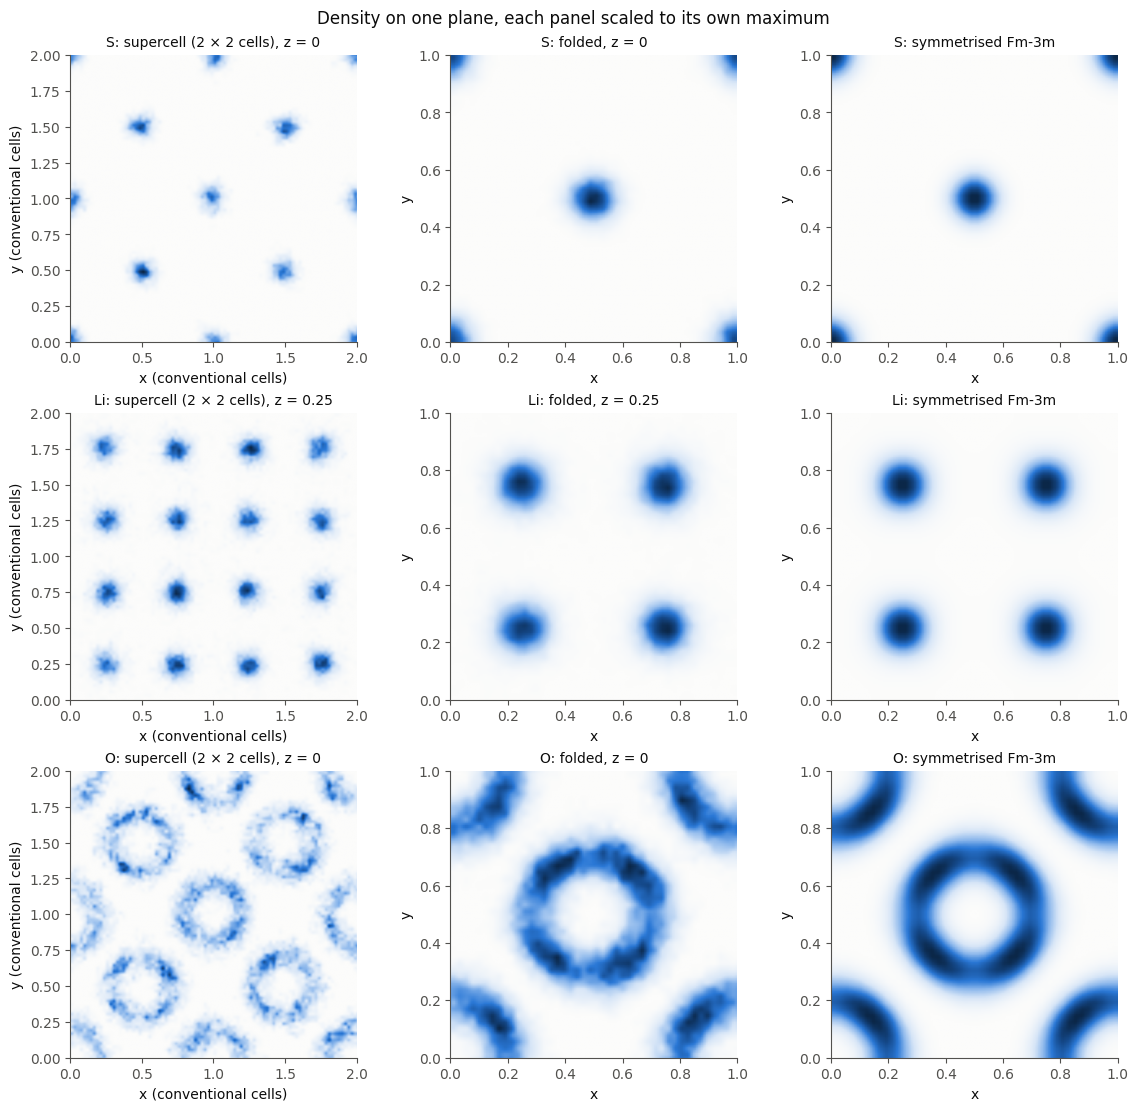

In [7]:
PLANES = {'S': 0.0, 'Li': 0.25, 'O': 0.0}  # z of the plane shown per species
fig, axs = plt.subplots(3, 3, figsize=(11.5, 11), layout='constrained')
for row, sp in zip(axs, SPECIES):
    z = PLANES[sp]
    images = [
        plane(raw[sp], (0, 0, z / 2), (1, 0, 0), (0, 1, 0), n=352),
        plane(folded[sp], (0, 0, z), (1, 0, 0), (0, 1, 0)),
        plane(density[sp], (0, 0, z), (1, 0, 0), (0, 1, 0)),
    ]
    titles = [
        f'{sp}: supercell (2 × 2 cells), z = {z:g}',
        f'{sp}: folded, z = {z:g}',
        f'{sp}: symmetrised Fm-3m',
    ]
    extents = [(0, 2, 0, 2), (0, 1, 0, 1), (0, 1, 0, 1)]
    for ax, image, title, extent in zip(row, images, titles, extents):
        show(ax, image / image.max(), vmin=0, vmax=1, title=title, extent=extent)
    row[0].set(xlabel='x (conventional cells)', ylabel='y (conventional cells)')
fig.suptitle('Density on one plane, each panel scaled to its own maximum', color=INK)
plt.show()

Sulfur is sharp and sits on the face-centred sites. Lithium sits on the tetrahedral 8c
sites (the z = ¼ plane contains a square of them) with a faint bridge through the
octahedral 4b sites. Oxygen forms rings around each S rather than four points.

Folding and symmetrising make a large difference to the noise, especially for O, whose
density is spread over many voxels: the supercell plane is speckled, the symmetrised
plane is smooth. Everything below is fit to the symmetrised grids (`symmetrize=False`,
since they already are).

## 3. Sulfur on 4a

One isotropic Gaussian per 4a site. The only free parameter is its width.

In [8]:
fit_S = fit_density_model(
    density['S'],
    'Fm-3m',
    [{'specie': 'S', 'position': (0, 0, 0)}],
    symmetrize=False,
    cell_length=a,
    seed=0,
    coarsen=2,
)
voxel_U = (a / density['S'].shape[0]) ** 2 / 12  # variance of the binning itself
display(sites_table(fit_S))
pd.Series(
    {
        'U_iso, this fit (Å²)': fit_S.sites[0].u_iso,
        'of which binning, h²/12 (Å²)': voxel_U,
        'U_iso, Table I (Å²)': TABLE_I['S 4a U_iso'],
        'R1-like': fit_S.metrics['r1_like'],
        'Pearson r': fit_S.metrics['pearson_r'],
    }
).round(4).to_frame('S')

,specie,multiplicity,position,density fraction,site occupancy,U_iso (Å²),split (Å)
0,S,4,"(0.0, 0.0, 0.0)",1.0,1.0,0.1256,None


,S
"U_iso, this fit (Å²)",0.1256
"of which binning, h²/12 (Å²)",0.0022
"U_iso, Table I (Å²)",0.1340
R1-like,0.0245
Pearson r,0.9998


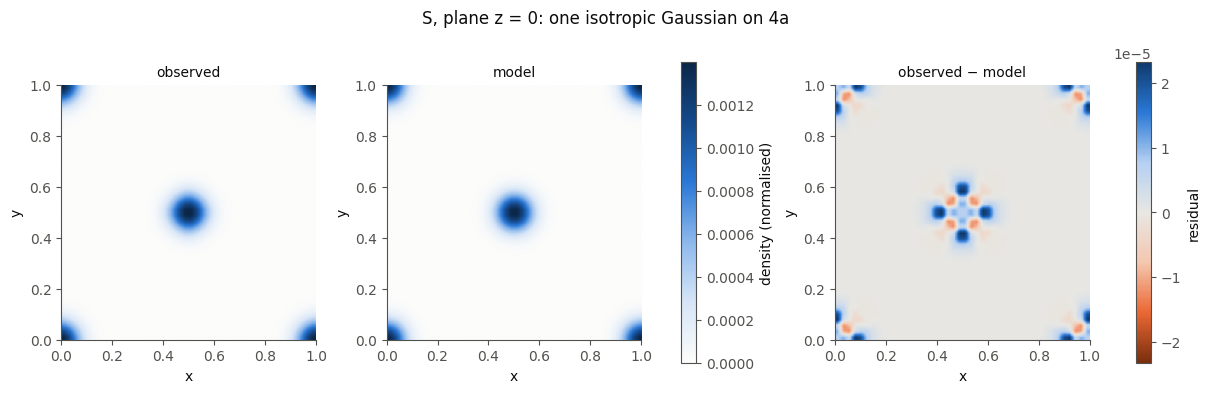

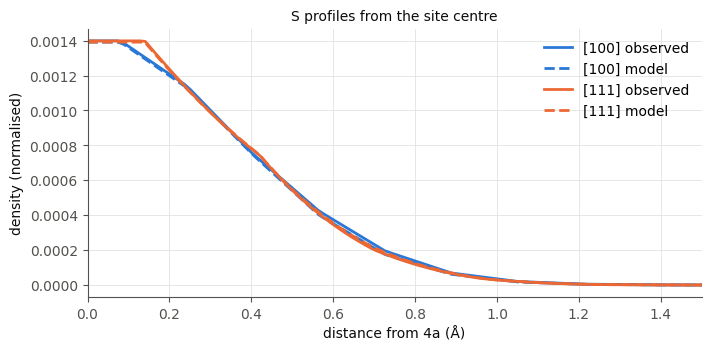

In [9]:
fig = compare_maps(
    density['S'],
    fit_S.model_density,
    origin=(0, 0, 0),
    e1=(1, 0, 0),
    e2=(0, 1, 0),
    title='S, plane z = 0: one isotropic Gaussian on 4a',
)
plt.show()

fig, ax = plt.subplots(figsize=(7, 3.4), layout='constrained')
for direction, color, label in [
    ((0.5, 0, 0), BLUE, '[100]'),
    ((0.25, 0.25, 0.25), ORANGE, '[111]'),
]:
    for grid, ls, kind in [
        (density['S'], '-', 'observed'),
        (fit_S.model_density, '--', 'model'),
    ]:
        t, values = line(grid / grid.sum(), (0, 0, 0), direction)
        r = t * np.linalg.norm(direction) * a
        ax.plot(r, values, color=color, ls=ls, label=f'{label} {kind}')
ax.set(
    xlabel='distance from 4a (Å)',
    ylabel='density (normalised)',
    title='S profiles from the site centre',
    xlim=(0, 1.5),
)
ax.legend()
plt.show()

The S density is close to an isotropic Gaussian: R1 ≈ 0.02, and the profiles along [100]
and [111] overlap. The residual is small (about 2 % of the peak) but not random. It has
the cubic pattern of a slightly anisotropic site: more density than the model along
⟨100⟩, towards the empty octahedral sites, and less along ⟨110⟩, towards the
neighbouring S.
*U*<sub>iso</sub> ≈ 0.126 Å², and 0.002 Å² of that is the bin width. The reference
`fit_densities_S.py` gives the same σ on this trajectory (0.04985 in both). Table I
lists 0.134 Å², so the manuscript table was made from a different state of the
analysis, not from this cache.

## 4. Lithium

### 4a. Two sites, or a split tetrahedral site?

Model 1 (Table I): isotropic Gaussians on the tetrahedral 8c and octahedral 4b sites, with
three parameters (two widths and the tetrahedral fraction).
Model 2: the 8c site is allowed to split along ⟨111⟩, which turns it into 32f
(x, x, x). That adds one parameter. `free_position=(1, 1, 1)` is how to ask for this: 8c
has no free coordinate of its own.

In [10]:
li_models = {
    '8c + 4b': [
        {'specie': 'Li', 'position': (0.25, 0.25, 0.25)},
        {'specie': 'Li', 'position': (0.5, 0.5, 0.5)},
    ],
    '32f + 4b (split)': [
        {
            'specie': 'Li',
            'position': (0.25, 0.25, 0.25),
            'free_position': (1, 1, 1),
            'max_displacement': 0.1,
        },
        {'specie': 'Li', 'position': (0.5, 0.5, 0.5)},
    ],
}
li_fits = {
    name: fit_density_model(
        density['Li'], 'Fm-3m', sites, symmetrize=False, cell_length=a, seed=0, coarsen=2
    )
    for name, sites in li_models.items()
}

display(pd.concat({name: sites_table(fit) for name, fit in li_fits.items()}))
best_bic = min(fit.metrics['bic'] for fit in li_fits.values())
pd.DataFrame(
    {
        name: {
            'parameters': len(fit.params),
            'R1-like': round(fit.metrics['r1_like'], 4),
            'wR-like': round(fit.metrics['wr_like'], 4),
            'BIC': round(fit.metrics['bic']),
            'ΔBIC': round(fit.metrics['bic'] - best_bic),
        }
        for name, fit in li_fits.items()
    }
)

/tmp/ipykernel_45113/1027590545.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  display(pd.concat({name: sites_table(fit) for name, fit in li_fits.items()}))


specie  multiplicity               position  \
8c + 4b          0     Li             8     (0.25, 0.25, 0.25)   
                 1     Li             4        (0.5, 0.5, 0.5)   
32f + 4b (split) 0     Li            32  (0.278, 0.278, 0.278)   
                 1     Li             4        (0.5, 0.5, 0.5)   

                    density fraction  site occupancy  U_iso (Å²)  split (Å)  
8c + 4b          0            0.7034          0.7034      0.1822        NaN  
                 1            0.2966          0.5932      0.6692        NaN  
32f + 4b (split) 0            0.6997          0.1749      0.1383      0.345  
                 1            0.3003          0.6006      0.6746        NaN

,8c + 4b,32f + 4b (split)
parameters,3.000000e+00,4.000000e+00
R1-like,1.785000e-01,1.514000e-01
wR-like,1.087000e-01,9.020000e-02
BIC,-2.148336e+06,-2.180185e+06
ΔBIC,3.184900e+04,0.000000e+00


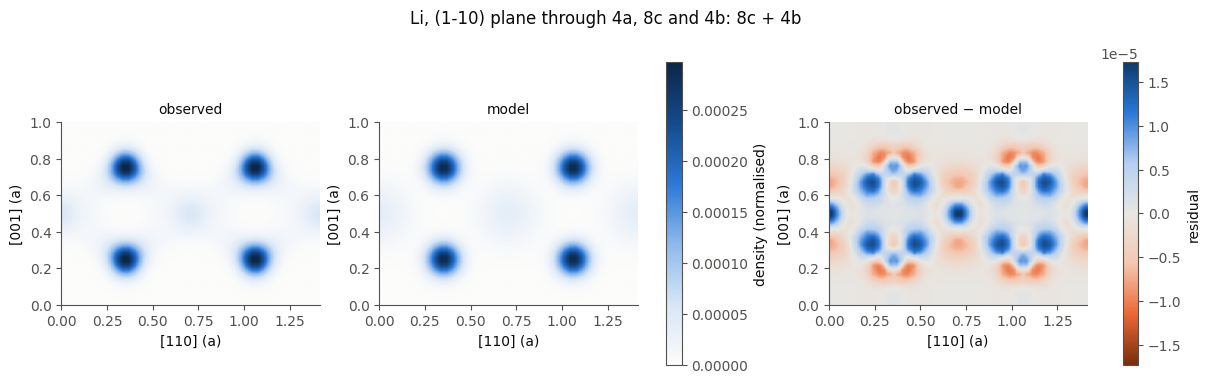

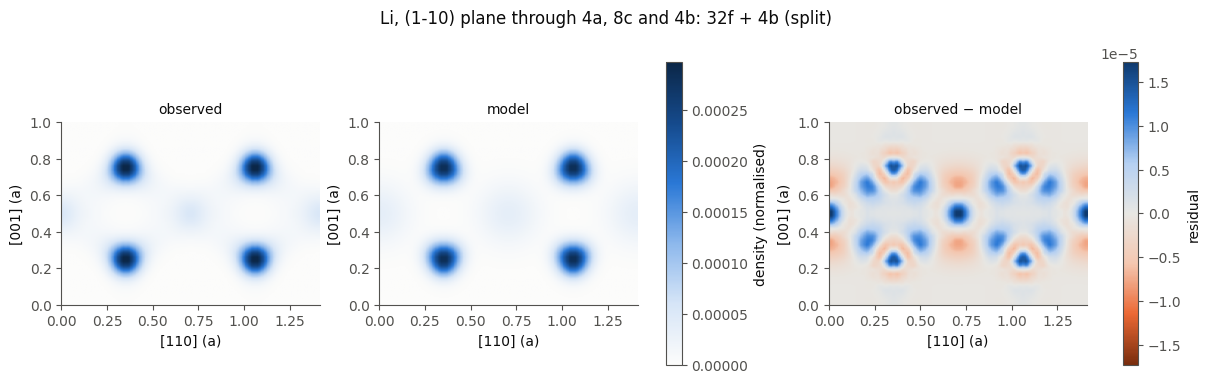

In [11]:
for name, fit in li_fits.items():
    compare_maps(
        density['Li'],
        fit.model_density,
        **DIAGONAL_PLANE,
        extent=(0, np.sqrt(2), 0, 1),
        labels=('[110] (a)', '[001] (a)'),
        title=f'Li, (1-10) plane through 4a, 8c and 4b: {name}',
    )
    plt.show()

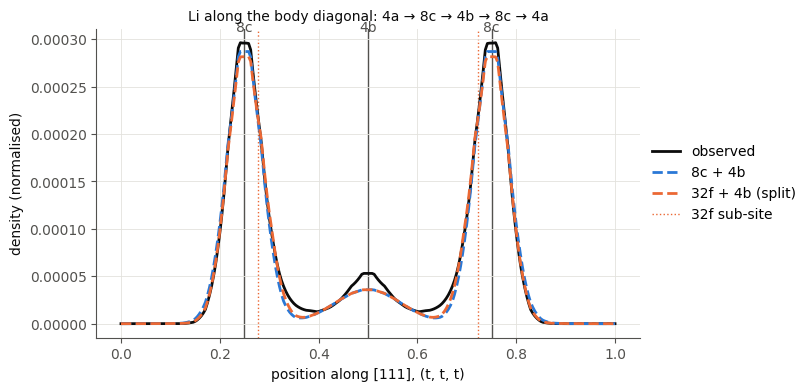

In [12]:
fig, ax = plt.subplots(figsize=(8, 3.8), layout='constrained')
t, observed = line(density['Li'] / density['Li'].sum(), (0, 0, 0), (1, 1, 1))
ax.plot(t, observed, color=INK, label='observed')
for (name, fit), color in zip(li_fits.items(), (BLUE, ORANGE)):
    ax.plot(
        t, line(fit.model_density, (0, 0, 0), (1, 1, 1))[1], color=color, ls='--', label=name
    )
x_split = li_fits['32f + 4b (split)'].sites[0].position[0]
for x, label in [(0.25, '8c'), (0.5, '4b'), (0.75, '8c')]:
    ax.axvline(x, color=MUTED, lw=1, zorder=0)
    ax.text(x, observed.max() * 1.04, label, ha='center', color=MUTED)
for x in (x_split, 1 - x_split):
    ax.axvline(
        x, color=ORANGE, lw=1, ls=':', zorder=0, label='32f sub-site' if x == x_split else None
    )
ax.set(
    xlabel='position along [111], (t, t, t)',
    ylabel='density (normalised)',
    title='Li along the body diagonal: 4a → 8c → 4b → 8c → 4a',
)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

Both models put about **70 %** of the Li density on the tetrahedral sites and 30 % on the
octahedral site, whose Gaussian is broad (*U* ≈ 0.67 Å²).

Splitting 8c into 32f lowers R1 from 0.179 to 0.151 and BIC by 3.2×10⁴. The four sub-sites
sit 0.35 Å from the tetrahedral centre along ⟨111⟩, through the faces of the S₄
tetrahedron towards the neighbouring octahedral sites. That is the start of the
tet → oct → tet hopping path, and it supports conclusion 3 of the manuscript (a four-way
split tetrahedral site).

Neither model gets the octahedral site right, and that misfit sets the colour scale of
both residual maps, so they look alike. The observed 4b density is a narrow peak on a
broad base (the profile at t = ½ stands well above both models), and one isotropic
Gaussian cannot follow that. A second 4b Gaussian, or a split 4b, would be the next
model to try.

BIC treats every voxel as an independent data point, but neighbouring voxels are
correlated, so read ΔBIC as "clearly better", not as a calibrated likelihood ratio.

The fractions differ from Table I (0.866 on 8c). `fit_densities_Li.py` run on this cache
gives the module's numbers to within 0.002 (0.7036, *U* 0.1825 / 0.6673 Å²;
split x = 0.2781), so again Table I does not come from this trajectory as-is.

### 4b. Is there really an inversion centre?

Fm-3m makes all eight tetrahedral sites equivalent. Its non-centrosymmetric subgroup
F-43m splits them into 4c (¼, ¼, ¼) and 4d (¾, ¾, ¾), each with its own width and
fraction. `rank_spacegroups` fits both groups (each to the grid symmetrised with that
group), then scores each model on the same folded but *unsymmetrised* grid, so the
comparison is fair.

In [13]:
ranking = rank_spacegroups(
    folded['Li'],
    ['Fm-3m', 'F-43m'],
    [
        [
            {'specie': 'Li', 'position': (0.25, 0.25, 0.25)},
            {'specie': 'Li', 'position': (0.5, 0.5, 0.5)},
        ],
        [
            {'specie': 'Li', 'position': (0.25, 0.25, 0.25)},
            {'specie': 'Li', 'position': (0.75, 0.75, 0.75)},
            {'specie': 'Li', 'position': (0.5, 0.5, 0.5)},
        ],
    ],
    cell_length=a,
    maxiter=100,
    popsize=15,
    coarsen=2,
)
best = ranking[0].ranking_metrics['bic']
pd.DataFrame(
    [
        {
            'space group': r.spacegroup_symbol,
            'parameters': len(r.params),
            'sites (fraction, U_iso)': ', '.join(
                f'{tuple(float(v) for v in np.round(s.position, 2))}: {s.occupancy:.4f}, {s.u_iso:.4f}'
                for s in r.sites
            ),
            'R1-like (common grid)': round(r.ranking_metrics['r1_like'], 4),
            'ΔBIC (common grid)': round(r.ranking_metrics['bic'] - best, 1),
        }
        for r in ranking
    ]
)

,space group,parameters,"sites (fraction, U_iso)",R1-like (common grid),ΔBIC (common grid)
0,F-43m,5,"(0.25, 0.25, 0.25): 0.3513, 0.1827, (0.75, 0.7...",0.2627,0.0
1,Fm-3m,3,"(0.25, 0.25, 0.25): 0.7034, 0.1822, (0.5, 0.5,...",0.2627,9.8


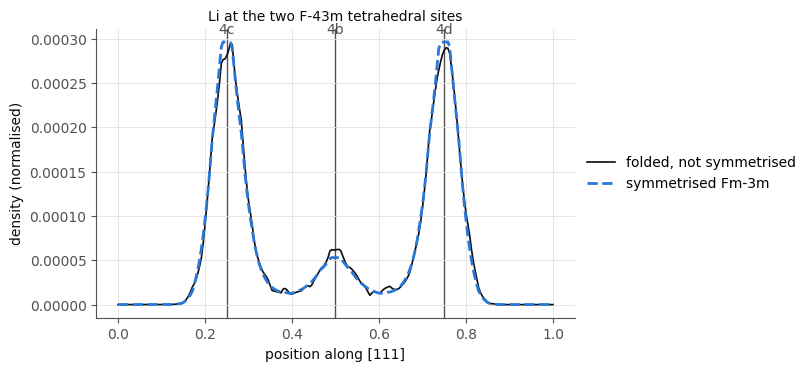

In [14]:
fig, ax = plt.subplots(figsize=(8, 3.6), layout='constrained')
t, observed = line(folded['Li'] / folded['Li'].sum(), (0, 0, 0), (1, 1, 1))
ax.plot(t, observed, color=INK, lw=1.2, label='folded, not symmetrised')
t, symmetric = line(density['Li'] / density['Li'].sum(), (0, 0, 0), (1, 1, 1))
ax.plot(t, symmetric, color=BLUE, ls='--', label='symmetrised Fm-3m')
for x, label in [(0.25, '4c'), (0.5, '4b'), (0.75, '4d')]:
    ax.axvline(x, color=MUTED, lw=1, zorder=0)
    ax.text(x, observed.max() * 1.04, label, ha='center', color=MUTED)
ax.set(
    xlabel='position along [111]',
    ylabel='density (normalised)',
    title='Li at the two F-43m tetrahedral sites',
)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

F-43m technically ranks first, but only by ΔBIC ≈ 10 and with the same R1 to four
decimals. Its fit *is* the Fm-3m fit: 4c and 4d get fractions 0.351 and 0.352 and widths
0.183 and 0.182 Å², and together with 4b (0.297, 0.669 Å²) that is the Fm-3m result split
in two. A ΔBIC of 10 is noise here (compare 3×10⁴ for the 32f split above), since BIC
counts 85 184 correlated voxels as independent data. The unsymmetrised profile has the
same peak height at ¼ and ¾. There is no sign of a broken inversion centre, and Fm-3m,
the simpler group, stays the right description.

R1 on this common grid (0.26) is higher than on the symmetrised grid (0.18) because the
unsymmetrised density still carries all the sampling noise that symmetrising averages
out.

## 5. Oxygen

### 5a. Where do the O atoms sit around S?

Sample the symmetrised O density on spheres centred on the S at the origin. The spherical
average gives the S–O distance, and the density on that sphere shows which directions
the O atoms prefer.

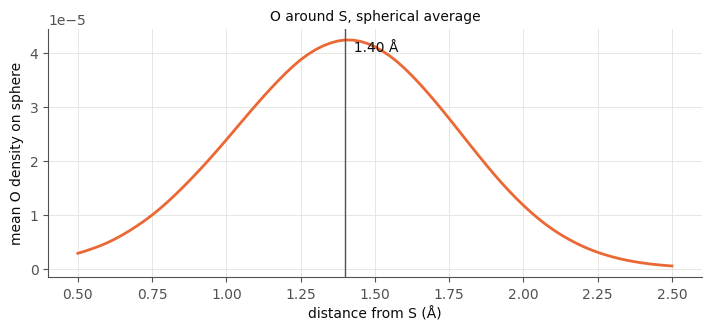

In [15]:
rng = np.random.default_rng(0)
directions = rng.normal(size=(20000, 3))
directions /= np.linalg.norm(directions, axis=1, keepdims=True)
radii = np.linspace(0.5, 2.5, 81)
O_norm = density['O'] / density['O'].sum()
radial = np.array([sample(O_norm, directions * r / a).mean() for r in radii])
r_SO = radii[np.argmax(radial)]

fig, ax = plt.subplots(figsize=(7, 3.2), layout='constrained')
ax.plot(radii, radial, color=ORANGE)
ax.axvline(r_SO, color=MUTED, lw=1)
ax.text(r_SO, radial.max(), f'  {r_SO:.2f} Å', color=INK, va='top')
ax.set(
    xlabel='distance from S (Å)',
    ylabel='mean O density on sphere',
    title='O around S, spherical average',
)
plt.show()

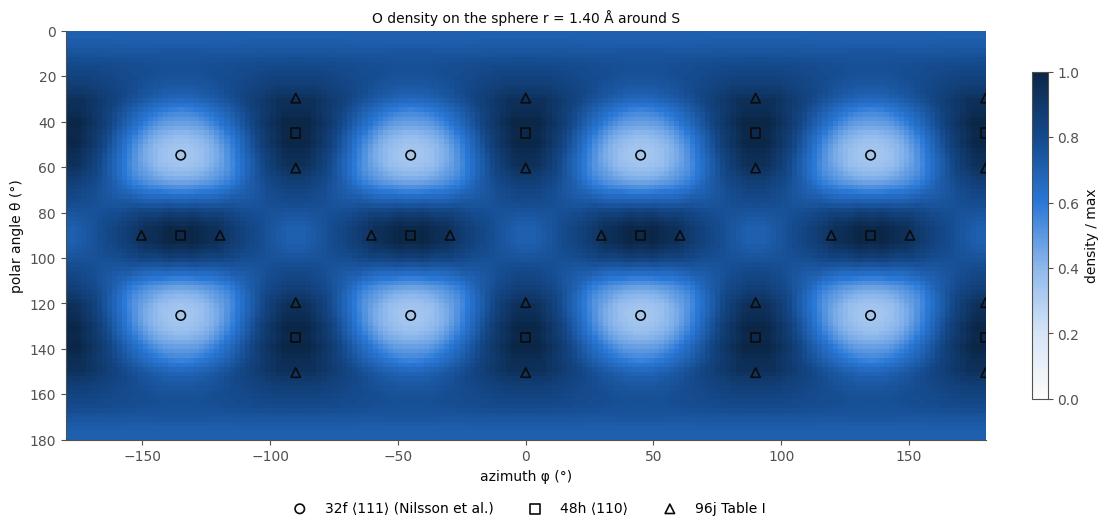

brightest direction → 96j start (0, 0.1290, 0.1484)


In [16]:
n_theta, n_phi = 90, 180
theta = (np.arange(n_theta) + 0.5) / n_theta * np.pi
phi = (np.arange(n_phi) + 0.5) / n_phi * 2 * np.pi - np.pi
T, P = np.meshgrid(theta, phi, indexing='ij')
unit = np.stack([np.sin(T) * np.cos(P), np.sin(T) * np.sin(P), np.cos(T)], axis=-1)
angular = sample(O_norm, unit * r_SO / a)

# The brightest direction, reduced by symmetry to (0, y, z) with y < z, seeds the 96j fit.
brightest = unit.reshape(-1, 3)[np.argmax(angular)] * r_SO / a
_, y0, z0 = np.sort(np.abs(brightest))


def orbit_directions(position, cutoff=0.3):
    # theta, phi (degrees) of the orbit members bound to the S at the origin.
    orbit = wyckoff_orbit('Fm-3m', position)
    vectors = orbit - np.round(orbit)
    vectors = vectors[np.linalg.norm(vectors, axis=1) < cutoff]
    vectors /= np.linalg.norm(vectors, axis=1, keepdims=True)
    return np.degrees(np.arccos(vectors[:, 2])), np.degrees(
        np.arctan2(vectors[:, 1], vectors[:, 0])
    )


fig, ax = plt.subplots(figsize=(11, 5.2), layout='constrained')
im = show(
    ax,
    angular / angular.max(),
    extent=(-180, 180, 0, 180),
    vmin=0,
    vmax=1,
    title=f'O density on the sphere r = {r_SO:.2f} Å around S',
    labels=('azimuth φ (°)', 'polar angle θ (°)'),
)
ax.set_aspect('auto')
ax.set_ylim(180, 0)
for position, marker, label in [
    ((0.12, 0.12, 0.12), 'o', '32f ⟨111⟩ (Nilsson et al.)'),
    ((0, 0.15, 0.15), 's', '48h ⟨110⟩'),
    ((0, TABLE_I['O 96j y'], TABLE_I['O 96j z']), '^', '96j Table I'),
]:
    th, ph = orbit_directions(position)
    ax.scatter(
        ph,
        th,
        marker=marker,
        s=46,
        facecolors='none',
        edgecolors=INK,
        linewidths=1.2,
        label=label,
    )
fig.colorbar(im, ax=ax, shrink=0.8, label='density / max')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3)
plt.show()
print(f'brightest direction → 96j start (0, {y0:.4f}, {z0:.4f})')

The spherical average peaks at 1.40 Å. That is a little short of the S–O bond, because the
shell is broad and a sphere samples it off-centre in most directions. On that sphere the
density is far from uniform, which rules out a spherical shell (the Kaber et al.
model). The ⟨111⟩ directions of the 32f model are *minima*. The density is highest in
twelve elongated nodes around ⟨110⟩, and the 48h and 96j positions of Table I both lie
in them, as in Fig. 3 of the manuscript. At this grid resolution the map cannot show
whether each node is one site (48h) or two overlapping ones (96j). The fit decides.

### 5b. Which Wyckoff model fits?

The three candidate O models, each with a free position within its Wyckoff position
(`free_position=True`: x for 32f (x, x, x), y for 48h (0, y, y), and y, z for 96j
(0, y, z)) and one isotropic width. All are Fm-3m fits to the same symmetrised grid, so
their metrics compare directly. The 96j fit starts from the brightest direction of the
map above, not from Table I.

These are the slow fits: each 96j evaluation builds 96 Gaussians on the 44³ grid, so they
use `workers=2` (about 3 minutes in total here).

In [17]:
o_models = {
    '32f (x, x, x)': (0.12, 0.12, 0.12),
    '48h (0, y, y)': (0.0, 0.15, 0.15),
    '96j (0, y, z)': (0.0, y0, z0),
}
o_fits = {
    name: fit_density_model(
        density['O'],
        'Fm-3m',
        [{'specie': 'O', 'position': start, 'free_position': True}],
        symmetrize=False,
        cell_length=a,
        seed=0,
        coarsen=2,
        maxiter=60,
        popsize=10,
        max_displacement=0.08,
        workers=2,
    )
    for name, start in o_models.items()
}

best_bic = min(fit.metrics['bic'] for fit in o_fits.values())


def canonical(fit):
    # Minimum-image representative; sorting |x|, |y|, |z| picks the symmetry-equivalent (x ≤ y ≤ z) setting.
    position = fit.sites[0].position
    return position - np.round(position)


pd.DataFrame(
    [
        {
            'model': name,
            'parameters': len(fit.params),
            'position (0 ≤ x ≤ y ≤ z)': tuple(
                float(v) for v in np.round(np.sort(np.abs(canonical(fit))), 4)
            ),
            'S–O (Å)': round(np.linalg.norm(fit.sites[0].position) * a, 3),
            'site occupancy': round(16 / fit.sites[0].multiplicity, 4),
            'U_iso (Å²)': round(fit.sites[0].u_iso, 4),
            'R1-like': round(fit.metrics['r1_like'], 4),
            'Pearson r': round(fit.metrics['pearson_r'], 4),
            'ΔBIC': round(fit.metrics['bic'] - best_bic),
        }
        for name, fit in o_fits.items()
    ]
).set_index('model')

,parameters,position (0 ≤ x ≤ y ≤ z),S–O (Å),site occupancy,U_iso (Å²),R1-like,Pearson r,ΔBIC
model,,,,,,,,
"32f (x, x, x)",2,"(0.11, 0.11, 0.11)",1.355,0.5000,0.4241,0.6469,0.7118,265027
"48h (0, y, y)",2,"(0.0, 0.1435, 0.1435)",1.443,0.3333,0.2191,0.4081,0.8744,201681
"96j (0, y, z)",3,"(0.0, 0.099, 0.1837)",1.484,0.1667,0.1493,0.1287,0.9891,0


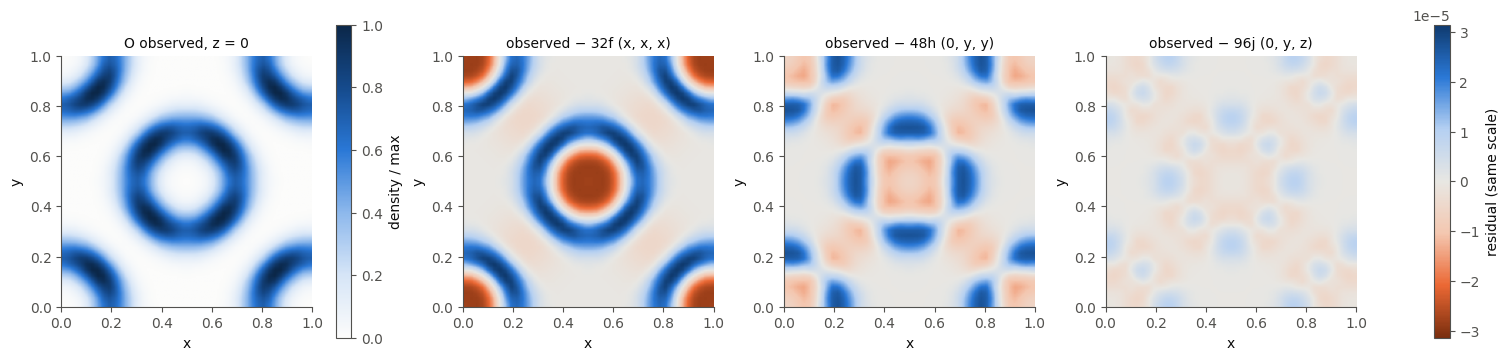

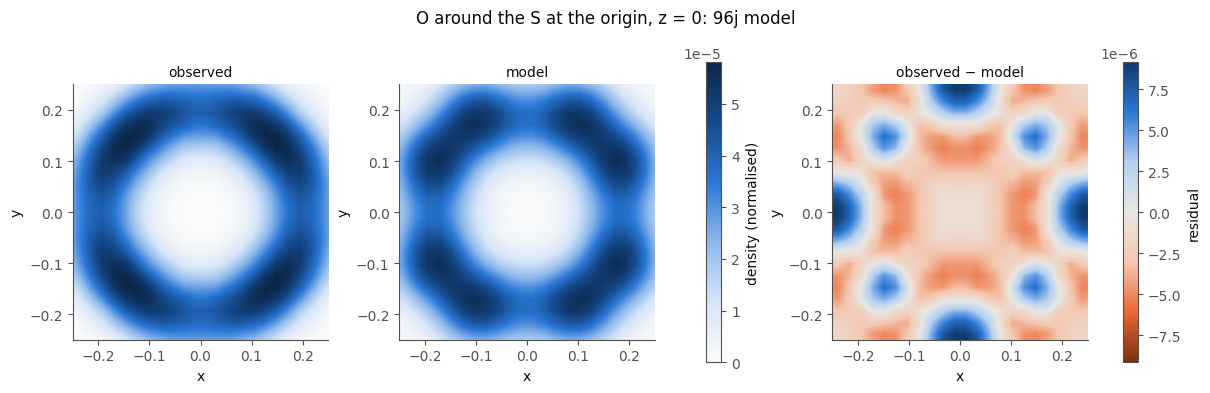

In [18]:
o_plane = plane(O_norm, (0, 0, 0), (1, 0, 0), (0, 1, 0))
residuals = {
    name: o_plane
    - plane(fit.model_density / fit.model_density.sum(), (0, 0, 0), (1, 0, 0), (0, 1, 0))
    for name, fit in o_fits.items()
}
rmax = max(np.abs(r).max() for r in residuals.values())

fig, axs = plt.subplots(1, 4, figsize=(15, 4), layout='constrained')
im = show(axs[0], o_plane / o_plane.max(), vmin=0, vmax=1, title='O observed, z = 0')
for ax, (name, res) in zip(axs[1:], residuals.items()):
    im2 = show(ax, res, cmap=DIV, vmin=-rmax, vmax=rmax, title=f'observed − {name}')
fig.colorbar(im, ax=axs[0], shrink=0.8, label='density / max')
fig.colorbar(im2, ax=axs[1:], shrink=0.8, label='residual (same scale)')
plt.show()

zoom = dict(origin=(-0.25, -0.25, 0), e1=(0.5, 0, 0), e2=(0, 0.5, 0))
fig = compare_maps(
    density['O'],
    o_fits['96j (0, y, z)'].model_density,
    **zoom,
    extent=(-0.25, 0.25, -0.25, 0.25),
    title='O around the S at the origin, z = 0: 96j model',
)
plt.show()

96j wins by far: R1 0.13 against 0.41 for 48h and 0.65 for 32f, and the residual maps
(all on one colour scale) show why. 32f puts the density in the wrong directions. 48h
leaves a strong pattern around each node, because one Gaussian cannot be both as long
and as narrow as the node. The 96j residual is several times weaker. The refined 96j
position (0, 0.099, 0.184) is 0.04 Å from Table I's (0, 0.1011, 0.1779), and the fitted
S–O distance is 1.48 Å.

The 96j residual that remains is not random either. The observed density fills in the
gap between the two sites of each pair (blue, on ⟨110⟩), and the model is too high on
the sites themselves (orange). A sulfate O swings further along the ring (rotation)
than along the S–O bond, which is what Table I's anisotropic *U* tensor describes. The
module fits isotropic Gaussians only, so its *U*<sub>iso</sub> = 0.149 Å² is a
compromise, below the mean of Table I's diagonal (0.182 Å²).

## 6. Summary

The refined average structure, and the observed density next to the model density in 3D.
The isosurfaces are drawn at the same absolute levels in both panels: 50 % of the
observed maximum for S, 30 % for Li and 85 % for O. At that O level the observed shell
breaks up into twelve lobes along ⟨110⟩ around each S. In the model each lobe is a pair
of 96j sites.

In [19]:
fit_O = o_fits['96j (0, y, z)']
two_site, split = li_fits['8c + 4b'], li_fits['32f + 4b (split)']
this_work = {
    'S 4a U_iso': fit_S.sites[0].u_iso,
    'Li tetrahedral fraction': two_site.sites[0].occupancy,
    'Li 8c U_iso': two_site.sites[0].u_iso,
    'Li 4b U_iso': two_site.sites[1].u_iso,
    'O 96j y': np.sort(np.abs(canonical(fit_O)))[1],
    'O 96j z': np.sort(np.abs(canonical(fit_O)))[2],
    'O 96j U_eq': fit_O.sites[0].u_iso,
}
summary = pd.DataFrame({'this notebook': this_work, 'Table I': TABLE_I})
summary.loc['Li 32f x (split model)', 'this notebook'] = split.sites[0].position[0]
summary.loc['Li 32f split (Å)', 'this notebook'] = split.sites[0].displacement
summary.round(4)

,this notebook,Table I
S 4a U_iso,0.1256,0.1340
Li tetrahedral fraction,0.7034,0.8660
Li 8c U_iso,0.1822,0.2140
Li 4b U_iso,0.6692,0.6340
O 96j y,0.0990,0.1011
O 96j z,0.1837,0.1779
O 96j U_eq,0.1493,0.1821
Li 32f x (split model),0.2780,NaN
Li 32f split (Å),0.3453,NaN


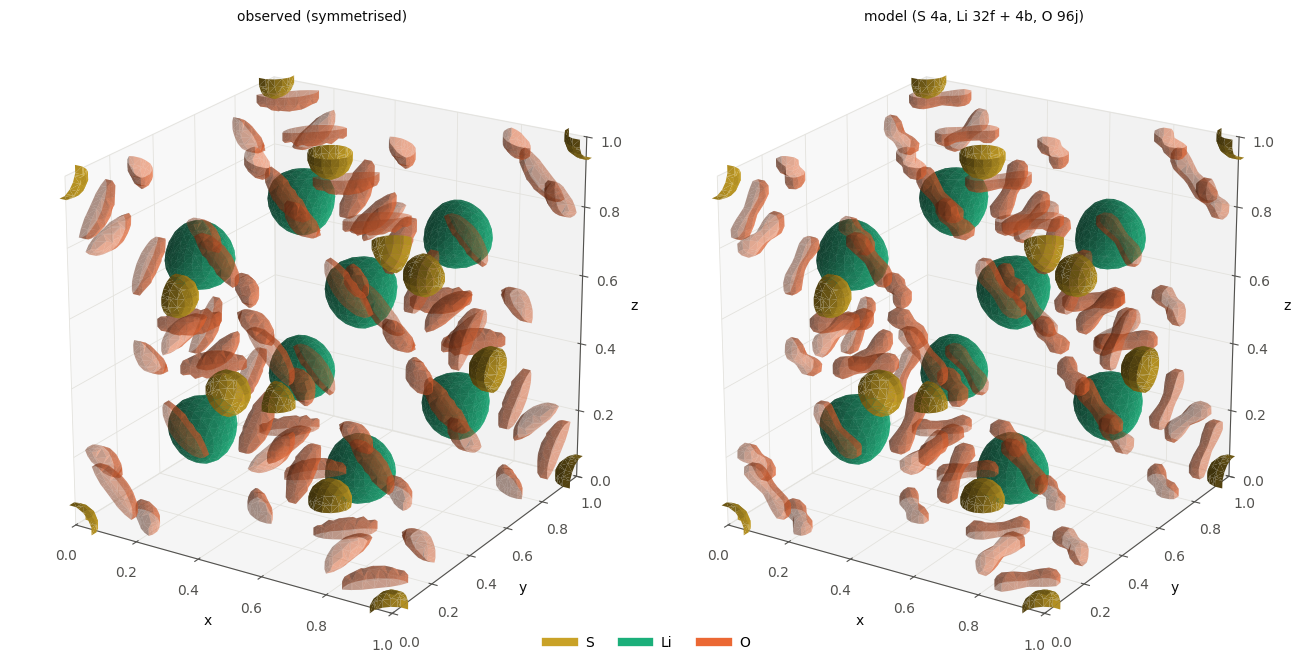

In [20]:
models = {'S': fit_S.model_density, 'Li': split.model_density, 'O': fit_O.model_density}
fig = plt.figure(figsize=(13, 6.5), layout='constrained')
for col, (title, grids) in enumerate(
    [('observed (symmetrised)', density), ('model (S 4a, Li 32f + 4b, O 96j)', models)]
):
    ax = fig.add_subplot(1, 2, col + 1, projection='3d')
    for sp, level, alpha in [('S', 0.5, 1.0), ('Li', 0.3, 0.8), ('O', 0.85, 0.5)]:
        obs = density[sp] / density[sp].sum()
        isosurface(ax, grids[sp] / grids[sp].sum(), level * obs.max(), COLORS[sp], alpha=alpha)
    ax.set(
        xlim=(0, 1), ylim=(0, 1), zlim=(0, 1), xlabel='x', ylabel='y', zlabel='z', title=title
    )
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=22, azim=-58)
fig.legend(
    handles=[plt.Line2D([], [], color=COLORS[sp], lw=6, label=sp) for sp in SPECIES],
    loc='lower center',
    ncol=3,
)
plt.show()

What this trajectory shows, with the module alone:

- **No origin shift is needed.** The S drift correction already centres the S sublattice
  on 4a. The shift fitted by the reference script is half a voxel, from its `i/n` voxel
  convention.
- **S** on 4a is an isotropic Gaussian with *U*<sub>iso</sub> ≈ 0.126 Å².
- **Li** has ≈70 % of its density on the tetrahedral sites and ≈30 % on a broad
  octahedral site. The tetrahedral site is split four ways (32f, x ≈ 0.278, 0.35 Å
  towards the octahedral sites), and that model is clearly better than 8c + 4b. The
  octahedral site is not a single Gaussian. F-43m reproduces the Fm-3m fit (4c = 4d), so the inversion centre holds.
- **O** sits on 96j (0, y, z) at y, z close to Table I, i.e. six superposed D₂d sulfate
  orientations. 32f (cubic average) and 48h (the ⟨110⟩ nodes) fit much worse.

Where the notebook differs from Table I: the S *U*<sub>iso</sub> and the Li fractions
and widths. On this cache, the reference scripts reproduce the notebook's values, not
the table's, so the table was made from a different state of the analysis. The O
anisotropic *U* tensor is out of scope, because the module fits isotropic Gaussians
only.